# 01 - EDA e Baselines (Telco Customer Churn)

Este notebook cobre a **Etapa 1** do Tech Challenge:
- carga e validação do dataset
- EDA (volume, qualidade, distribuições e correlações)
- definição de métricas técnicas e estimativa de métrica de negócio
- execução dos modelos baseline com MLflow


In [4]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from churn_predictor.data import (
    clean_telco_dataset,
    dataset_version_hash,
    download_dataset_if_needed,
    load_dataset,
)
from churn_predictor.logging_utils import configure_logging, log_event
from churn_predictor.pipelines.baselines import BusinessMetricConfig, run_baselines

sns.set_theme(style="whitegrid")
configure_logging(logging.INFO)
LOGGER = logging.getLogger("notebook.eda_baselines")

In [5]:
dataset_path = download_dataset_if_needed()
df_raw = load_dataset(dataset_path)
df = clean_telco_dataset(df_raw)

dataset_hash = dataset_version_hash(df)

log_event(
    LOGGER,
    "dataset_loaded_for_eda",
    event="dataset_loaded_for_eda",
    step="data_load",
)

pd.DataFrame(
    {
        "rows": [df.shape[0]],
        "columns": [df.shape[1]],
        "dataset_path": [str(dataset_path)],
        "dataset_version_hash": [dataset_hash],
    }
)

2026-04-09 15:30:48,539 | INFO | churn_predictor.data | dataset_download_started
2026-04-09 15:30:48,933 | INFO | churn_predictor.data | dataset_download_completed
2026-04-09 15:30:48,958 | INFO | churn_predictor.data | dataset_loaded
2026-04-09 15:30:49,014 | INFO | notebook.eda_baselines | {'message': 'dataset_loaded_for_eda', 'event': 'dataset_loaded_for_eda', 'model': 'n/a', 'step': 'data_load'}


,rows,columns,dataset_path,dataset_version_hash
0,7043,20,data\raw\telco_customer_churn.csv,720603b4b4e5d9b9ca1a477444859ed6a9dd24879e5c2e...


In [6]:
missing_df = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda d: (d["missing_count"] / len(df)) * 100)
    .sort_values("missing_count", ascending=False)
)

missing_df.head(15)

,missing_count,missing_pct
TotalCharges,11,0.156183
gender,0,0.000000
Partner,0,0.000000
SeniorCitizen,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
MultipleLines,0,0.000000
PhoneService,0,0.000000
OnlineSecurity,0,0.000000
OnlineBackup,0,0.000000


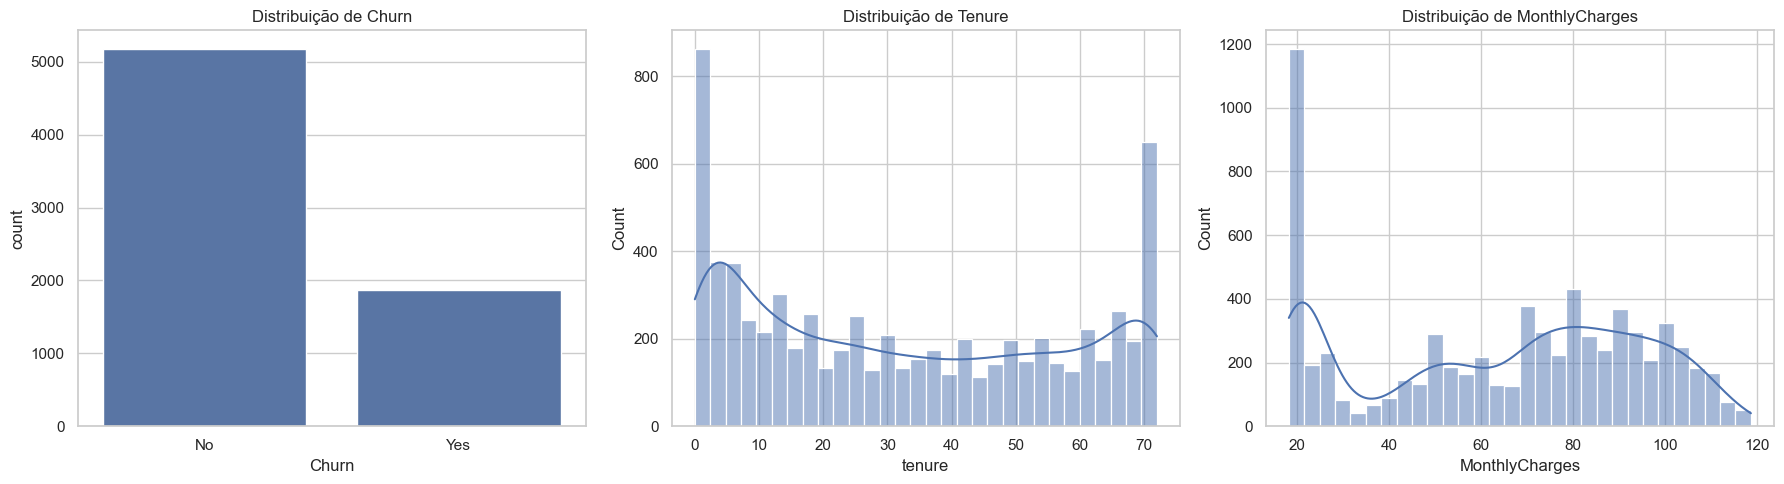

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Churn", ax=axes[0])
axes[0].set_title("Distribuição de Churn")

sns.histplot(data=df, x="tenure", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribuição de Tenure")

sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True, ax=axes[2])
axes[2].set_title("Distribuição de MonthlyCharges")

plt.tight_layout()

In [8]:
churn_rate_by_contract = (
    df.groupby("Contract", dropna=False)["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .rename("churn_rate")
    .sort_values(ascending=False)
)

churn_rate_by_contract.to_frame()

,churn_rate
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


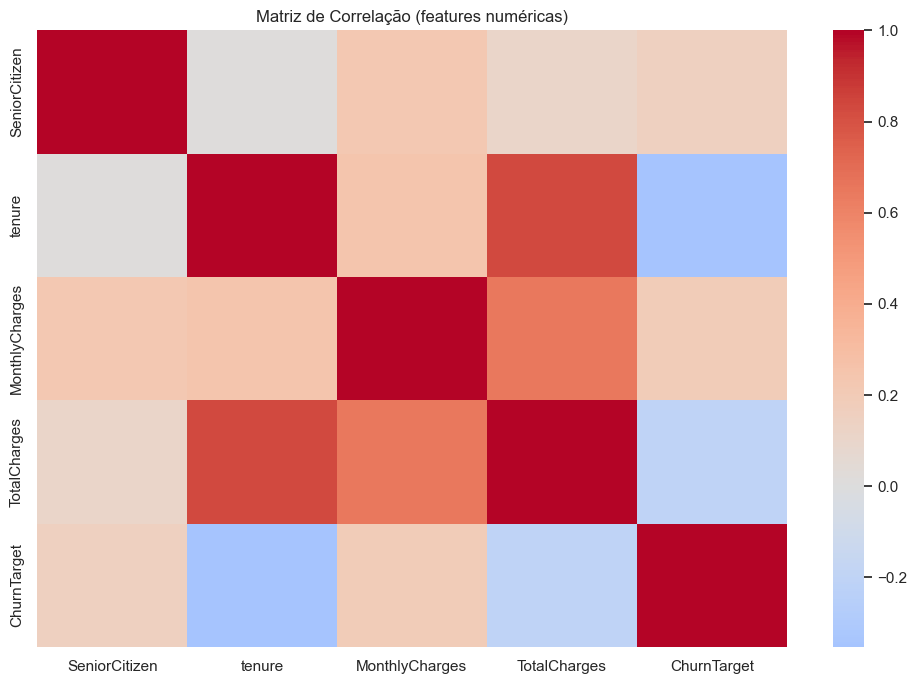

In [9]:
numeric_df = df.select_dtypes(include=["number"]).copy()

if "Churn" in df.columns:
    numeric_df["ChurnTarget"] = df["Churn"].map({"Yes": 1, "No": 0})

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação (features numéricas)")
plt.tight_layout()

## Métricas técnicas e de negócio

### Métricas técnicas
- **AUC-ROC**: capacidade de separação entre churn e não churn.
- **PR-AUC**: desempenho na classe positiva (churn), importante em possível desbalanceamento.
- **F1-Score**: equilíbrio entre precisão e recall.

### Estimativa de métrica de negócio
No baseline, a métrica é estimada por:

$$\text{valor\_líquido\_estimado} = (TP \cdot p_{retenção} \cdot V_{churn}) - ((TP + FP) \cdot C_{contato})$$

Onde:
- $TP$: churners corretamente identificados
- $FP$: não churners acionados indevidamente
- $p_{retenção}$: taxa esperada de sucesso da ação de retenção
- $V_{churn}$: valor recuperado por churn evitado
- $C_{contato}$: custo de abordagem por cliente


In [10]:
business_cfg = BusinessMetricConfig()
pd.DataFrame(
    {
        "retention_success_rate": [business_cfg.retention_success_rate],
        "churn_prevention_value": [business_cfg.churn_prevention_value],
        "contact_cost": [business_cfg.contact_cost],
        "threshold": [business_cfg.threshold],
    }
)

,retention_success_rate,churn_prevention_value,contact_cost,threshold
0,0.35,300.0,12.0,0.5


In [11]:
metrics_df = run_baselines(
    experiment_name="telco-churn-baselines-stage1",
    random_state=42,
    test_size=0.2,
)

log_event(
    LOGGER,
    "baseline_models_executed",
    event="baseline_models_executed",
    step="baselines",
)

metrics_df

2026-04-09 15:31:28,603 | INFO | churn_predictor.data | dataset_download_skipped
2026-04-09 15:31:28,624 | INFO | churn_predictor.data | dataset_loaded
2026/04/09 15:31:28 INFO mlflow.tracking.fluent: Experiment with name 'telco-churn-baselines-stage1' does not exist. Creating a new experiment.
2026-04-09 15:31:28,698 | INFO | churn_predictor.pipelines.baselines | {'message': 'model_training_started', 'event': 'model_training_started', 'model': 'dummy_classifier', 'step': 'train'}
C:\Users\rique\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rique\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

,model,dataset_version_hash,auc_roc,pr_auc,f1_score,business_tp,business_fp,business_retained_customers_est,business_recovered_value_est,business_contact_cost_est,business_net_value_est
1,logistic_regression,720603b4b4e5d9b9ca1a477444859ed6a9dd24879e5c2e...,0.841861,0.633429,0.604046,209.0,109.0,73.15,21945.0,3816.0,18129.0
0,dummy_classifier,720603b4b4e5d9b9ca1a477444859ed6a9dd24879e5c2e...,0.500000,0.265436,0.000000,0.0,0.0,0.00,0.0,0.0,0.0


## Artefatos esperados após execução

- `models/baseline_metrics.csv`
- `models/reports/*.json`
- `mlruns/` com rastreamento de parâmetros, métricas e versão do dataset
